# What Makes a Spotify Song Popular?
## A Data Visualization Study Using Spotify Track Data

### Objective

Spotify hosts millions of songs with different audio characteristics. This project investigates which features are most associated with song popularity.

Key Questions:

1. What is the distribution of song popularity?
2. Which genres achieve the highest popularity?
3. Do explicit songs perform differently?
4. Are danceable songs more popular?
5. Does energy influence popularity?
6. How do audio characteristics differ between popular and unpopular songs?

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10,6)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


## Load Dataset

In [2]:
df = pd.read_csv("dataset.csv")
print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


## Dataset Overview

In [3]:
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          

In [4]:
print("Dataset overview:")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")


Dataset overview:
Number of rows: 114000
Number of columns: 21


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [6]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## Missing Values

In [7]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

## Data Quality Assessment

The dataset was examined for missing values and inconsistencies before visualization.

No major data quality issues were observed that would significantly affect the analysis.

## Data Visualization

### 1: Popularity Distribution

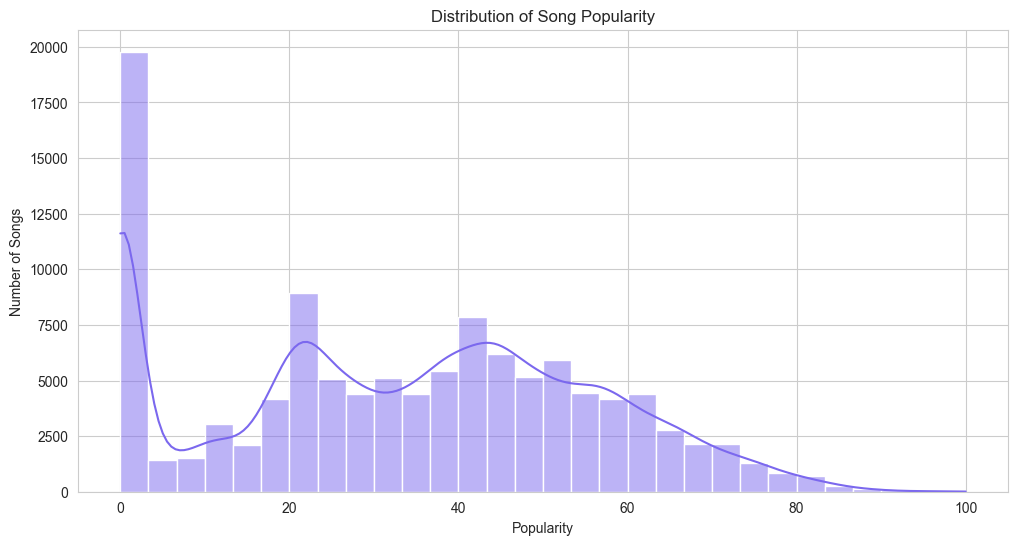

In [8]:
plt.figure(figsize=(12,6))

sns.histplot(
    df["popularity"],
    bins=30,
    kde=True,
    color="mediumslateblue"
)

plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Songs")

plt.show()

### Insight

Most tracks fall within low to moderate popularity ranges. Extremely popular songs represent a relatively small portion of the dataset.

### 2: Top Genres By Average Popularity

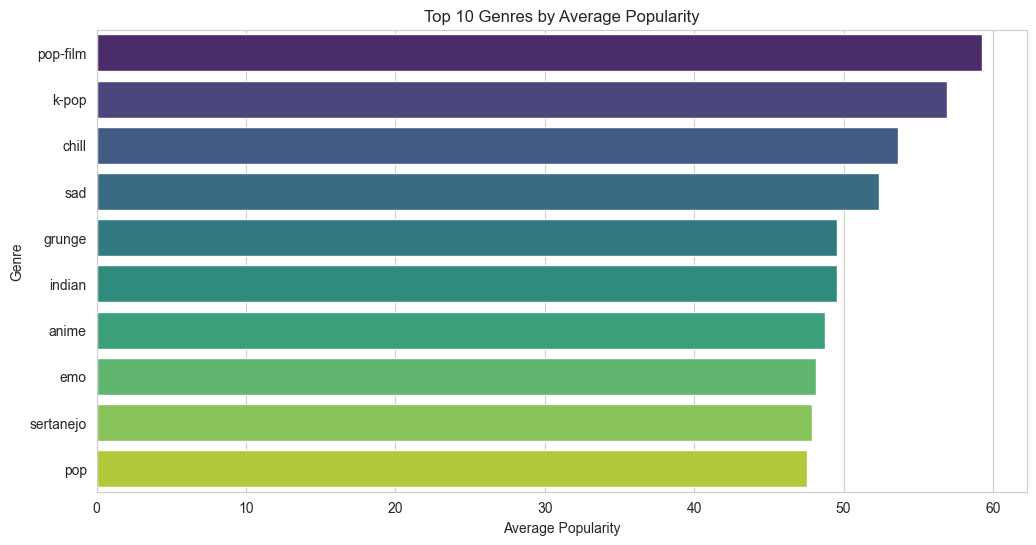

In [9]:
genre_popularity = (
    df.groupby("track_genre")["popularity"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=genre_popularity.values,
    y=genre_popularity.index,
    palette="viridis"
)

plt.title("Top 10 Genres by Average Popularity")

plt.xlabel("Average Popularity")
plt.ylabel("Genre")

plt.show()

### Insight

The most represented genres are not always the most popular. This suggests audience engagement differs across genres.

### 3: Explicit vs Non Explicit Songs

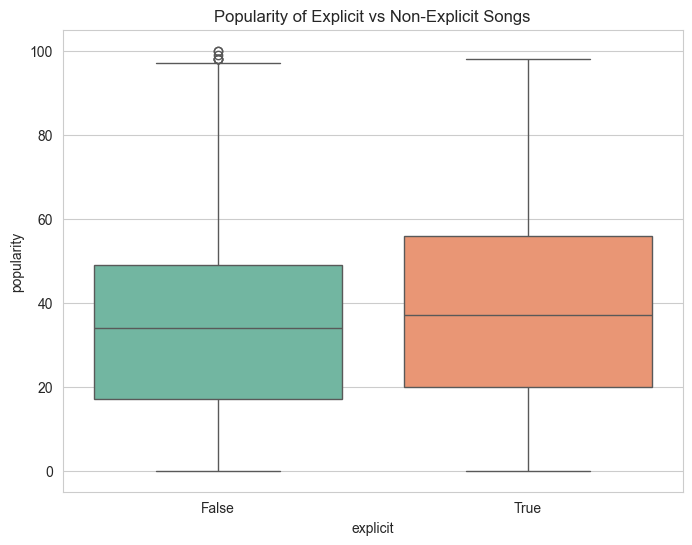

In [10]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="explicit",
    y="popularity",
    data=df,
    palette="Set2"
)

plt.title("Popularity of Explicit vs Non-Explicit Songs")

plt.show()

### Insight

This comparison helps determine whether explicit content influences audience engagement and popularity

### 4: Danceability vs Popularity

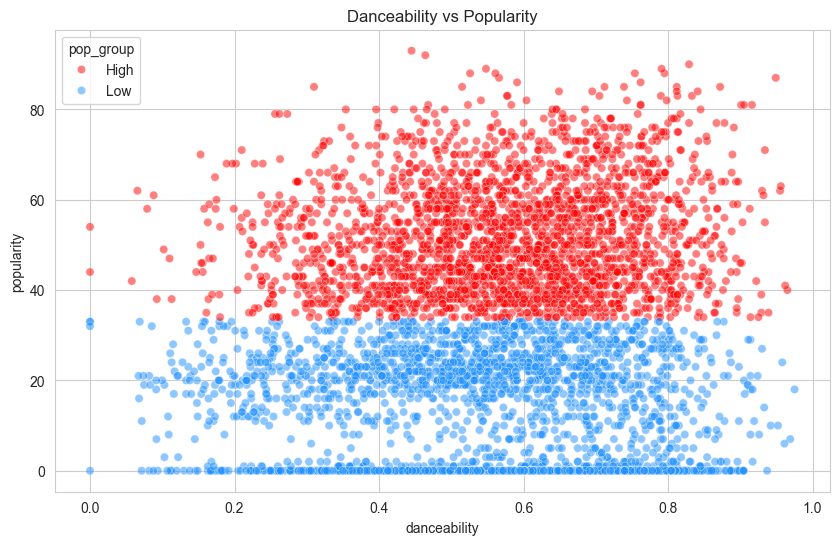

In [11]:
sample_df = df.sample(5000, random_state=42)

# create a simple split
sample_df["pop_group"] = sample_df["popularity"].apply(
    lambda x: "High" if x >= sample_df["popularity"].median() else "Low"
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    x="danceability",
    y="popularity",
    data=sample_df,
    hue="pop_group",
    palette={"High": "red", "Low": "dodgerblue"},
    alpha=0.5
)

plt.title("Danceability vs Popularity")
plt.show()

### Insight

Songs with higher danceability often appear among popular tracks, though the relationship is not perfectly linear.

### 5: Energy vs Popularity

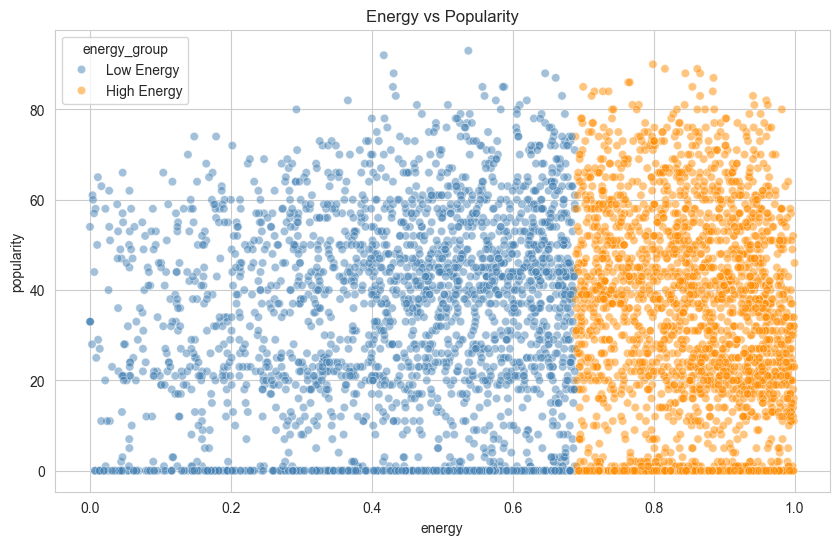

In [12]:
sample_df = df.sample(5000, random_state=42)

sample_df["energy_group"] = sample_df["energy"].apply(
    lambda x: "High Energy" if x >= sample_df["energy"].median() else "Low Energy"
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    x="energy",
    y="popularity",
    data=sample_df,
    hue="energy_group",
    palette={"High Energy": "darkorange", "Low Energy": "steelblue"},
    alpha=0.5
)

plt.title("Energy vs Popularity")
plt.show()

### Insight

High-energy songs are common across all popularity levels, indicating energy alone does not determine success.

### 6: Popular vs Unpopular Songs

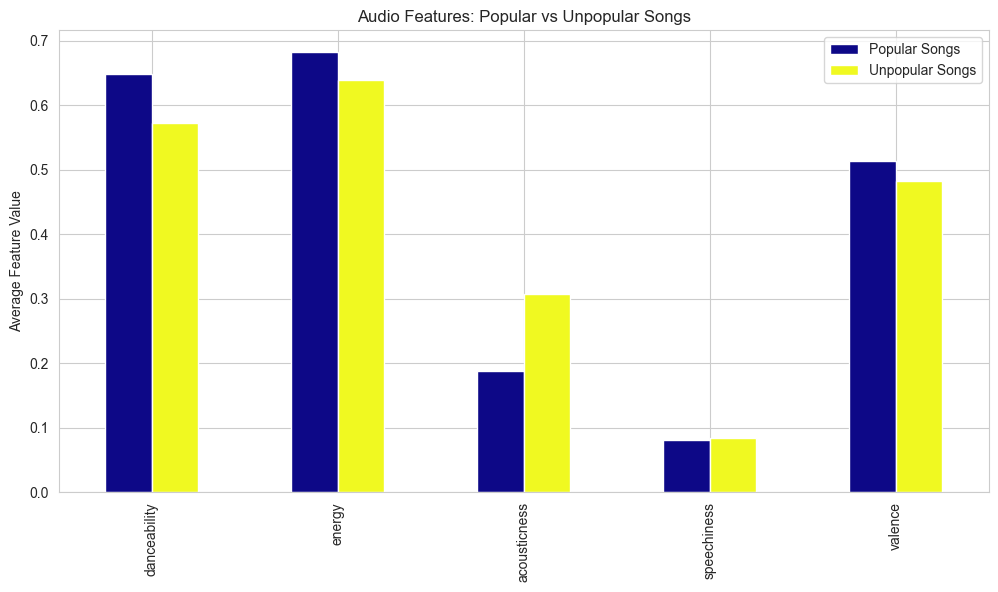

In [13]:
popular = df[df["popularity"] >= 80]

unpopular = df[df["popularity"] <= 20]

features = [
    "danceability",
    "energy",
    "acousticness",
    "speechiness",
    "valence"
]

comparison = pd.DataFrame({
    "Popular Songs": popular[features].mean(),
    "Unpopular Songs": unpopular[features].mean()
})

comparison.plot(
    kind="bar",
    figsize=(12,6),
    colormap="plasma"
)

plt.title(
    "Audio Features: Popular vs Unpopular Songs"
)

plt.ylabel("Average Feature Value")

plt.show()

### Insight

Popular songs exhibit noticeably different audio characteristics compared to unpopular songs. These differences provide clues about listener preferences.

### 7: Correlation Heatmap

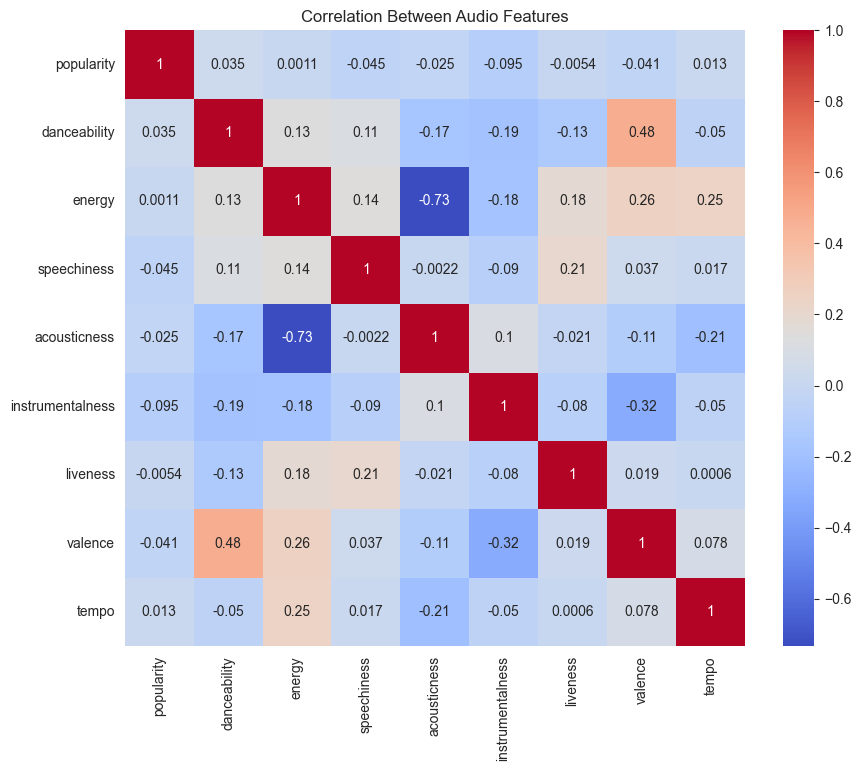

In [14]:
cols = [
    "popularity",
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df[cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Audio Features")
plt.show()


### Insight

Most audio features show weak individual relationships with popularity, suggesting song success is influenced by multiple factors.

### 8: Top Artists By Average Popularity

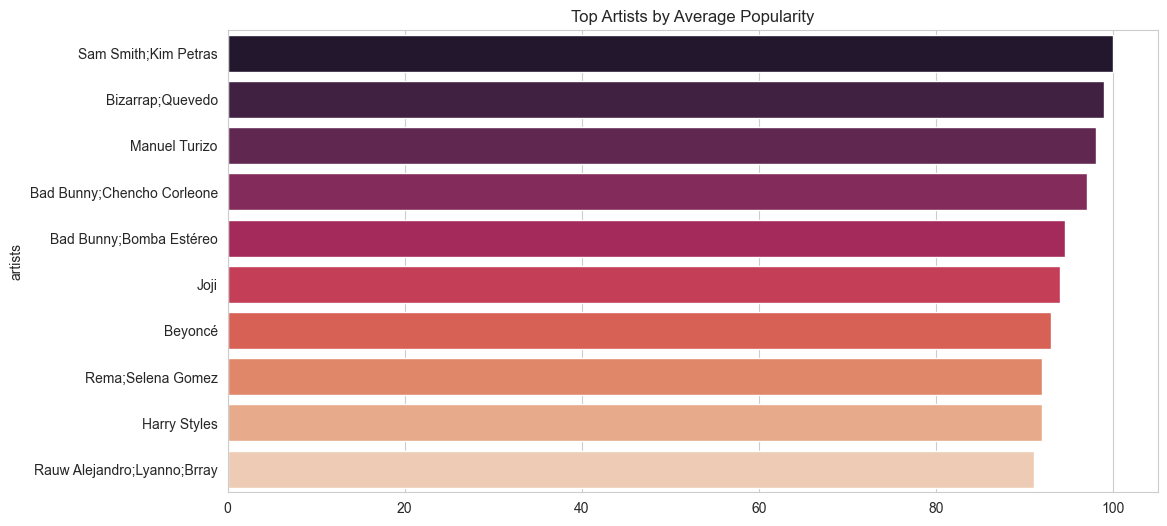

In [15]:
artist_pop = (
    df.groupby("artists")["popularity"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=artist_pop.values,
    y=artist_pop.index,
    palette="rocket"
)

plt.title("Top Artists by Average Popularity")

plt.show()

### Insight

Certain artists consistently achieve higher popularity, demonstrating strong audience reach and engagement.

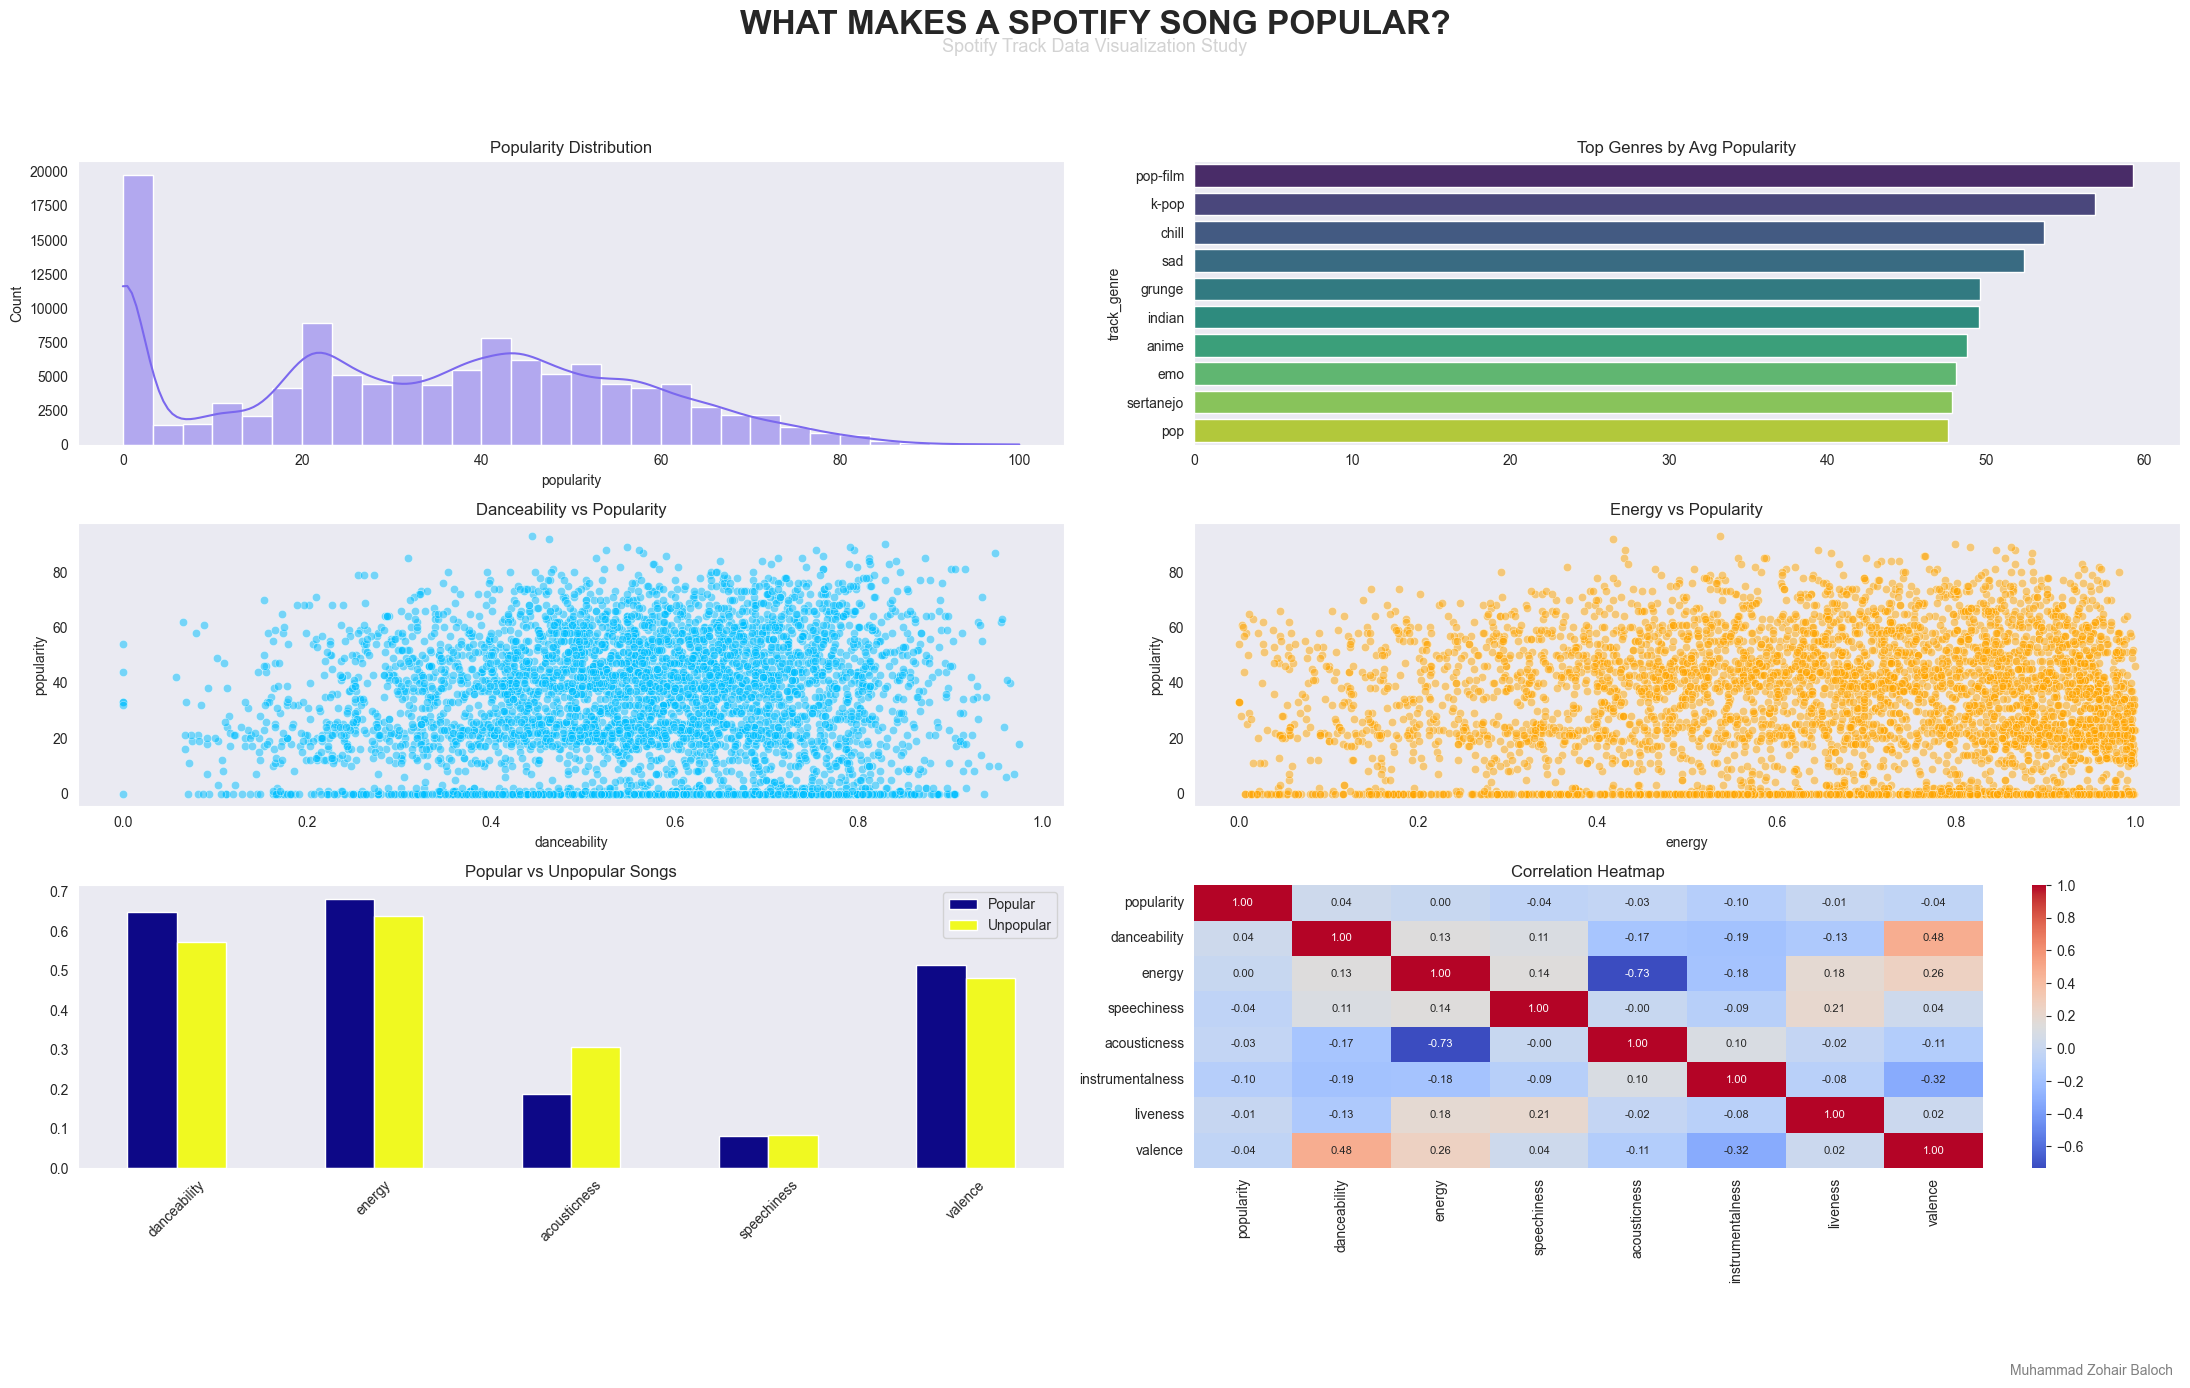

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# STYLE
# -----------------------------
plt.style.use("dark_background")
sns.set_style("dark")

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("dataset.csv")

# -----------------------------
# CREATE FIGURE
# -----------------------------
fig = plt.figure(figsize=(22, 14))

fig.suptitle(
    "WHAT MAKES A SPOTIFY SONG POPULAR?",
    fontsize=24,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.5,
    0.95,
    "Spotify Track Data Visualization Study",
    ha="center",
    fontsize=13,
    color="lightgray"
)

# =====================================================
# 1. POPULARITY DISTRIBUTION
# =====================================================

ax1 = plt.subplot(3, 2, 1)

sns.histplot(
    df["popularity"],
    bins=30,
    kde=True,
    color="mediumslateblue",
    ax=ax1
)

ax1.set_title("Popularity Distribution")

# =====================================================
# 2. TOP GENRES
# =====================================================

ax2 = plt.subplot(3, 2, 2)

genre_popularity = (
    df.groupby("track_genre")["popularity"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

sns.barplot(
    x=genre_popularity.values,
    y=genre_popularity.index,
    palette="viridis",
    ax=ax2
)

ax2.set_title("Top Genres by Avg Popularity")

# =====================================================
# 3. DANCEABILITY VS POPULARITY
# =====================================================

sample_df = df.sample(5000, random_state=42)

ax3 = plt.subplot(3, 2, 3)

sns.scatterplot(
    x="danceability",
    y="popularity",
    data=sample_df,
    alpha=0.5,
    color="deepskyblue",
    ax=ax3
)

ax3.set_title("Danceability vs Popularity")

# =====================================================
# 4. ENERGY VS POPULARITY
# =====================================================

ax4 = plt.subplot(3, 2, 4)

sns.scatterplot(
    x="energy",
    y="popularity",
    data=sample_df,
    alpha=0.5,
    color="orange",
    ax=ax4
)

ax4.set_title("Energy vs Popularity")

# =====================================================
# 5. POPULAR VS UNPOPULAR SONGS
# =====================================================

ax5 = plt.subplot(3, 2, 5)

popular = df[df["popularity"] >= 80]
unpopular = df[df["popularity"] <= 20]

features = [
    "danceability",
    "energy",
    "acousticness",
    "speechiness",
    "valence"
]

comparison = pd.DataFrame({
    "Popular": popular[features].mean(),
    "Unpopular": unpopular[features].mean()
})

comparison.plot(
    kind="bar",
    ax=ax5,
    colormap="plasma"
)

ax5.set_title("Popular vs Unpopular Songs")
ax5.tick_params(axis="x", rotation=45)

# =====================================================
# 6. HEATMAP
# =====================================================

ax6 = plt.subplot(3, 2, 6)

cols = [
    "popularity",
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence"
]

sns.heatmap(
    df[cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 8},
    ax=ax6
)

ax6.set_title("Correlation Heatmap")

# =====================================================
# INSIGHTS SECTION
# =====================================================

fig.text(
    0.5,
    0.02,
    """
Key Findings:
• Popular songs represent a small portion of the dataset
• Genre influences popularity levels
• Danceability shows stronger association with popularity than many other features
• Energy alone does not guarantee song success
• Popular songs exhibit distinct audio characteristics
• Song popularity depends on multiple factors rather than a single feature
    """,
    ha="center",
    fontsize=11,
    color="white"
)

# =====================================================
# AUTHOR
# =====================================================

fig.text(
    0.99,
    0.005,
    "Muhammad Zohair Baloch",
    ha="right",
    fontsize=10,
    color="gray"
)

# =====================================================
# SAVE
# =====================================================

plt.tight_layout(rect=[0, 0.06, 1, 0.93])

plt.savefig(
    "spotify_dashboard_cover.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Conclusion

This study explored the factors associated with Spotify song popularity through data visualization.

Key Findings:

- Popular songs represent a small fraction of all tracks.
- Genre influences popularity levels.
- Danceability appears more associated with popularity than several other audio features.
- Energy alone does not guarantee success.
- Popular songs display distinct audio characteristics compared to unpopular songs.
- Song popularity is influenced by a combination of factors rather than a single feature.

The analysis demonstrates how visualization can uncover meaningful insights from music streaming data and support data-driven understanding of listener behavior.